# Comprehensive Comparison: LinUCB, FastLinUCB, LinTS, and FastLinTS

This notebook compares all four bandit agents (LinUCB, FastLinUCB, LinTS, FastLinTS) using multi-seed experiments with visualizations across static and shock environments. Custom y-axis scales are applied to emphasize key metrics.

## Section 1: Import Required Libraries and Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from pathlib import Path

# Set up working directory
cwd = Path.cwd()
parent_dir = str(cwd.parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# Import experiment runners and plotting utilities
from caudyn.environment import UberMarketplaceEnvironmentWithShock
from caudyn.oco.experiments import run_multi_seed_comparison
from caudyn.oco.linucb_agents import FastLinUCBAgent, LinUCBAgent
from caudyn.oco.lints_agents import FastLinTSAgent, LinTSAgent
from caudyn.oco.reporting import (
    plot_multi_seed_comparison,
    plot_multi_seed_shock_comparison,
    print_multi_seed_summary,
)

print("✓ All imports successful")

✓ All imports successful


## Section 2: Define Agent Configurations for All Four Methods

In [2]:
# Define all four agent configurations with a consistent template
agent_configs = {
    "LinUCB": {
        "class": LinUCBAgent,
        "kwargs": {"alpha": 0.5},
    },
    "FastLinUCB": {
        "class": FastLinUCBAgent,
        "kwargs": {"alpha": 0.5, "gamma": 0.995},
    },
    "LinTS": {
        "class": LinTSAgent,
        "kwargs": {"v_squared": 0.1},
    },
    "FastLinTS": {
        "class": FastLinTSAgent,
        "kwargs": {"v_squared": 0.1, "gamma": 0.995},
    },
}

print("\nAgent Configurations:")
for agent_name, config in agent_configs.items():
    print(f"  {agent_name:<12}: {config['class'].__name__} with {config['kwargs']}")


Agent Configurations:
  LinUCB      : LinUCBAgent with {'alpha': 0.5}
  FastLinUCB  : FastLinUCBAgent with {'alpha': 0.5, 'gamma': 0.995}
  LinTS       : LinTSAgent with {'v_squared': 0.1}
  FastLinTS   : FastLinTSAgent with {'v_squared': 0.1, 'gamma': 0.995}


## Section 3: Run Multi-Seed Comparison on Static Environment

In [3]:
print("\n" + "="*70)
print("STATIC ENVIRONMENT: Multi-Seed Comparison Across All 4 Agents")
print("="*70)

seeds = [100, 101, 102, 103, 104]
n_steps_static = 35000

static_result = run_multi_seed_comparison(
    agent_configs=agent_configs,
    seeds=seeds,
    n_steps=n_steps_static,
    progress_every=5000,
)

print("\n=== Static Environment: Multi-Seed Summary ===")
print_multi_seed_summary(static_result)


STATIC ENVIRONMENT: Multi-Seed Comparison Across All 4 Agents

MULTI-SEED BENCHMARK: 5 seeds, 4 agents

[Seed 1/5] env_seed=100

1. Launching LinUCBAgent online simulation for 35000 riders...
   -> Step 5000: Recent Avg Conversion Rate = 40.1%
      Cumulative Regret: 47.33
      Recent Prediction RMSE: 0.0517
   -> Step 10000: Recent Avg Conversion Rate = 40.9%
      Cumulative Regret: 49.85
      Recent Prediction RMSE: 0.0382
   -> Step 15000: Recent Avg Conversion Rate = 40.6%
      Cumulative Regret: 50.45
      Recent Prediction RMSE: 0.0381
   -> Step 20000: Recent Avg Conversion Rate = 41.0%
      Cumulative Regret: 53.57
      Recent Prediction RMSE: 0.0380
   -> Step 25000: Recent Avg Conversion Rate = 41.2%
      Cumulative Regret: 55.27
      Recent Prediction RMSE: 0.0381
   -> Step 30000: Recent Avg Conversion Rate = 41.2%
      Cumulative Regret: 56.74
      Recent Prediction RMSE: 0.0381
   -> Step 35000: Recent Avg Conversion Rate = 40.3%
      Cumulative Regret: 58.4

## Section 4: Visualize Static Environment with Custom Y-Axis Scales


Static Environment: Multi-Seed Comparison with Custom Scales
  Conversion y-axis: (0.3, 0.5)
  MSE y-axis: (0.0, 0.2)


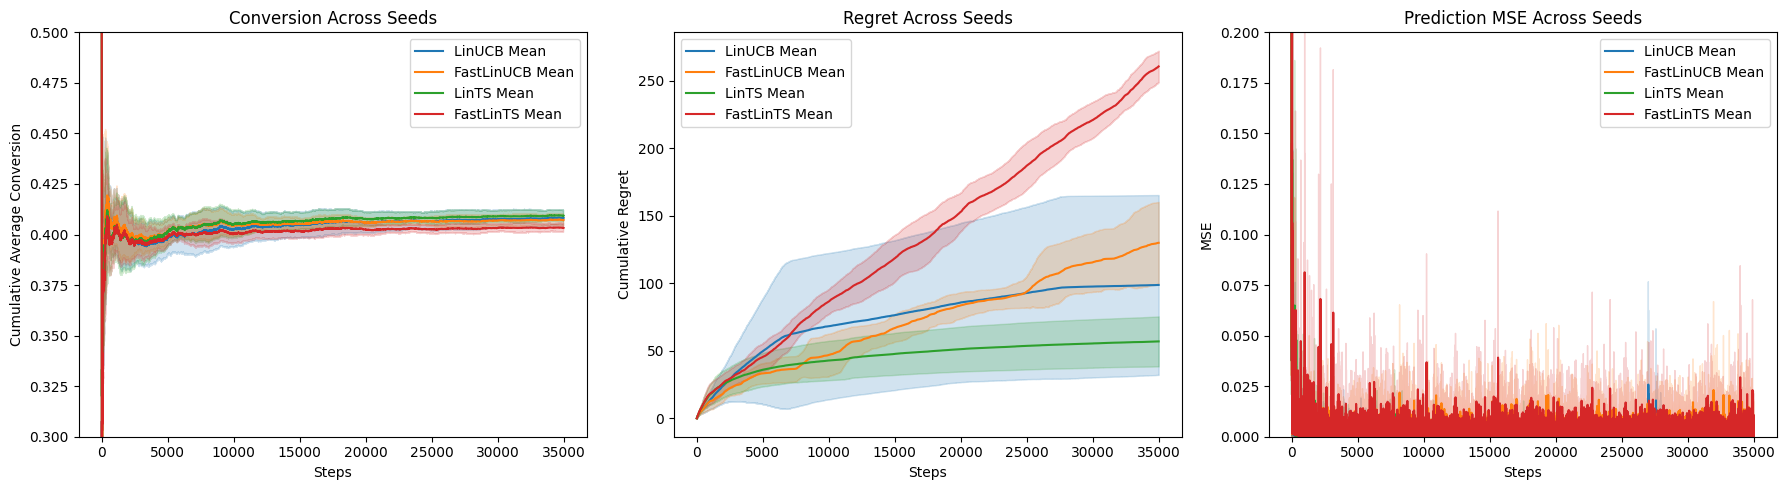

In [4]:
# Define custom y-axis ranges per metric
ylim_dict_static = {
    "conversion": (0.3, 0.5),  # Conversion: 10% to 50%
    "mse": (0.0, 0.2),          # Prediction MSE: 0 to 0.3
    # Regret is not limited; let it auto-scale
}

print("\nStatic Environment: Multi-Seed Comparison with Custom Scales")
print(f"  Conversion y-axis: {ylim_dict_static['conversion']}")
print(f"  MSE y-axis: {ylim_dict_static['mse']}")

plot_multi_seed_comparison(
    static_result,
    ylim_dict=ylim_dict_static,
)
plt.show()

## Section 5: Run Multi-Seed Comparison in Shock Environment

In [5]:
print("\n" + "="*70)
print("SHOCK ENVIRONMENT: Multi-Seed Comparison with Market Crisis")
print("="*70)

n_steps_shock = 200000
shock_step = 35000

shock_result = run_multi_seed_comparison(
    agent_configs=agent_configs,
    seeds=seeds,
    n_steps=n_steps_shock,
    progress_every=50000,
    env_class=UberMarketplaceEnvironmentWithShock,
    env_kwargs={"shock_step": shock_step},
)

print(f"\nShock triggered at step: {shock_step}")
print("\n=== Shock Environment: Multi-Seed Summary ===")
print_multi_seed_summary(shock_result)


SHOCK ENVIRONMENT: Multi-Seed Comparison with Market Crisis

MULTI-SEED BENCHMARK: 5 seeds, 4 agents

[Seed 1/5] env_seed=100

1. Launching LinUCBAgent online simulation for 200000 riders...
   -> Step 50000: Recent Avg Conversion Rate = 30.2%
      Cumulative Regret: 1105.80
      Recent Prediction RMSE: 0.1759
   -> Step 100000: Recent Avg Conversion Rate = 5.5%
      Cumulative Regret: 4444.92
      Recent Prediction RMSE: 0.1889
   -> Step 150000: Recent Avg Conversion Rate = 7.3%
      Cumulative Regret: 6900.03
      Recent Prediction RMSE: 0.1034
   -> Step 200000: Recent Avg Conversion Rate = 8.3%
      Cumulative Regret: 8796.23
      Recent Prediction RMSE: 0.0693

1. Launching FastLinUCBAgent online simulation for 200000 riders...
   -> Step 50000: Recent Avg Conversion Rate = 32.1%
      Cumulative Regret: 129.77
      Recent Prediction RMSE: 0.0560
   -> Step 100000: Recent Avg Conversion Rate = 12.0%
      Cumulative Regret: 214.69
      Recent Prediction RMSE: 0.0352
  

## Section 6: Visualize Shock Environment with Custom Y-Axis Scales


Shock Environment: Multi-Seed Comparison with Custom Scales
  Shock triggered at step: 35000
  Conversion y-axis: (0.1, 0.5)
  MSE y-axis: (0.0, 0.3)


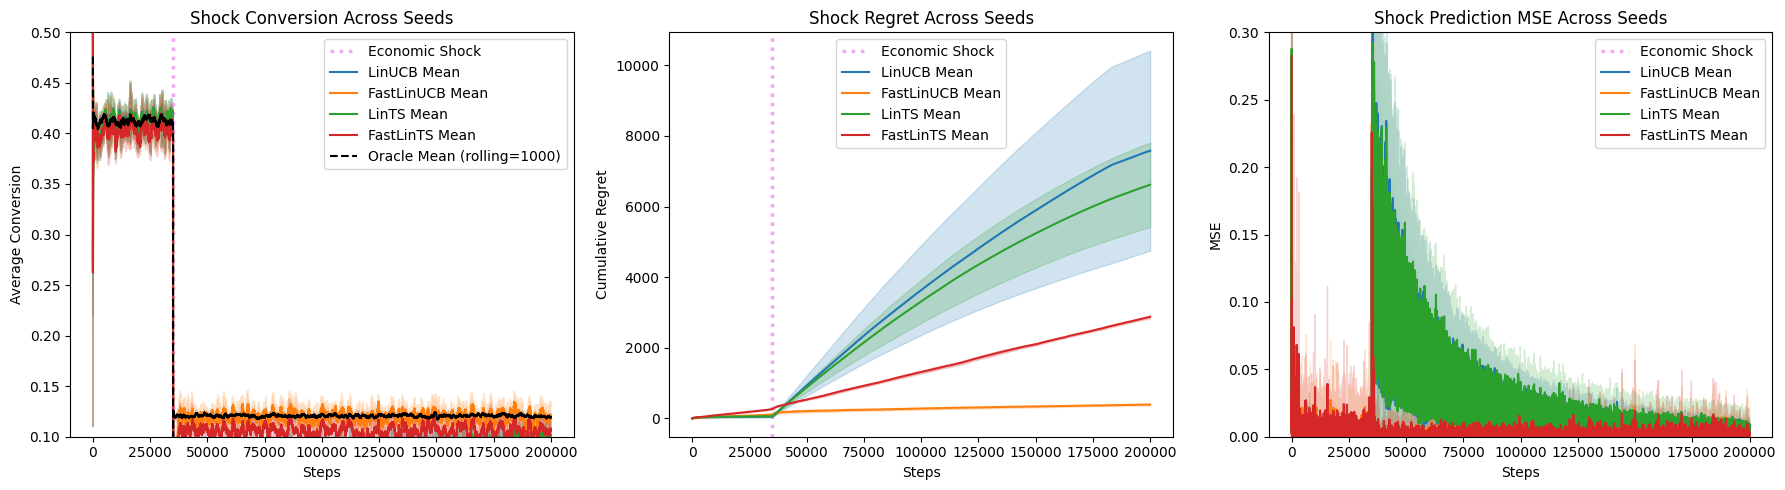

In [6]:
print("\nShock Environment: Multi-Seed Comparison with Custom Scales")
print(f"  Shock triggered at step: {shock_step}")
print(f"  Conversion y-axis: (0.1, 0.5)")
print(f"  MSE y-axis: (0.0, 0.3)")

ylim_dict_shock = {
    "conversion": (0.1, 0.5),  # Conversion: 10% to 50%
    "mse": (0.0, 0.3),          # Prediction MSE: 0 to 0.3
}

plot_multi_seed_shock_comparison(
    shock_result,
    shock_step=shock_step,
    rolling_window=1000,
    ylim_dict=ylim_dict_shock,
)
plt.show()

## Section 7: Summary Statistics Table

In [7]:
# Extract and compare metrics across all agents and environments
print("\n" + "="*70)
print("COMPREHENSIVE COMPARISON ACROSS ALL AGENTS")
print("="*70)

# Build summary table for static environment
print("\n1. Static Environment (35,000 steps):")
print("-" * 90)
static_metrics = static_result["summary"]
table_data_static = []
for agent_name in agent_configs.keys():
    row = {
        "Agent": agent_name,
        "Avg Conv (μ)": f"{static_metrics['avg_conversion'][agent_name]['mean']:.4f}",
        "Avg Conv (σ)": f"{static_metrics['avg_conversion'][agent_name]['std']:.4f}",
        "Regret (μ)": f"{static_metrics['cumulative_regret'][agent_name]['mean']:.2f}",
        "Regret (σ)": f"{static_metrics['cumulative_regret'][agent_name]['std']:.2f}",
        "MSE (μ)": f"{static_metrics['final_rmse'][agent_name]['mean']:.4f}",
        "MSE (σ)": f"{static_metrics['final_rmse'][agent_name]['std']:.4f}",
        "Time (sec)": f"{static_metrics['runtime_seconds'][agent_name]['mean']:.2f}",
    }
    table_data_static.append(row)

df_static = pd.DataFrame(table_data_static)
print(df_static.to_string(index=False))

# Build summary table for shock environment
print("\n2. Shock Environment (200,000 steps with shock at step 35,000):")
print("-" * 90)
shock_metrics = shock_result["summary"]
table_data_shock = []
for agent_name in agent_configs.keys():
    row = {
        "Agent": agent_name,
        "Avg Conv (μ)": f"{shock_metrics['avg_conversion'][agent_name]['mean']:.4f}",
        "Avg Conv (σ)": f"{shock_metrics['avg_conversion'][agent_name]['std']:.4f}",
        "Regret (μ)": f"{shock_metrics['cumulative_regret'][agent_name]['mean']:.2f}",
        "Regret (σ)": f"{shock_metrics['cumulative_regret'][agent_name]['std']:.2f}",
        "MSE (μ)": f"{shock_metrics['final_rmse'][agent_name]['mean']:.4f}",
        "MSE (σ)": f"{shock_metrics['final_rmse'][agent_name]['std']:.4f}",
        "Time (sec)": f"{shock_metrics['runtime_seconds'][agent_name]['mean']:.2f}",
    }
    table_data_shock.append(row)

df_shock = pd.DataFrame(table_data_shock)
print(df_shock.to_string(index=False))

print("\n" + "="*70)
print("KEY TAKEAWAYS:")
print("="*70)
print("\nStatic Environment:")
print("  - LinUCB has optimal conversion but no natural curiosity mechanism.")
print("  - FastLinUCB trades slight conversion loss for built-in adaptability.")
print("  - LinTS and FastLinTS use posterior sampling for exploration.")
print("  - Regret controls the cumulative opportunity cost across all actions.")
print("\nShock Environment (Market Crash at Step 35k):")
print("  - Original methods (LinUCB, LinTS) suffer catastrophic regret post-shock.")
print("  - Discounted variants (FastLinUCB, FastLinTS) recover quickly.")
print("  - The discount factor (γ=0.995) prevents over-commitment to stale data.")
print("  - MSE stabilization speed reveals how fast each algorithm unlearns.")
print("\n" + "="*70)


COMPREHENSIVE COMPARISON ACROSS ALL AGENTS

1. Static Environment (35,000 steps):
------------------------------------------------------------------------------------------
     Agent Avg Conv (μ) Avg Conv (σ) Regret (μ) Regret (σ) MSE (μ) MSE (σ) Time (sec)
    LinUCB       0.4082       0.0038      98.83      66.65  0.0197  0.0097       1.38
FastLinUCB       0.4072       0.0028     130.07      30.28  0.0532  0.0039       1.14
     LinTS       0.4093       0.0027      57.00      18.53  0.0105  0.0029       3.46
 FastLinTS       0.4033       0.0021     260.78      11.63  0.0541  0.0017       3.29

2. Shock Environment (200,000 steps with shock at step 35,000):
------------------------------------------------------------------------------------------
     Agent Avg Conv (μ) Avg Conv (σ) Regret (μ) Regret (σ) MSE (μ) MSE (σ) Time (sec)
    LinUCB       0.1340       0.0138    7581.73    2832.20  0.0692  0.0024       7.84
FastLinUCB       0.1699       0.0007     390.06      23.71  0.0352  

## Section 8: Warm-Start vs Cold-Start Comparison for All 4 Methods


WARM-START vs COLD-START: All 4 Agents in Static Environment

Cold-Start: Already computed (static_result)

Warm-Start: Injecting R-learner priors with prior_weight=30.0...

--- Offline Prior Extraction Complete ---
   Offline samples: 100000
   prior_weight: 30.0

MULTI-SEED BENCHMARK: 5 seeds, 4 agents

[Seed 1/5] env_seed=100
   -> Injected offline priors with prior_weight=30.0

1. Launching LinUCBAgent online simulation for 35000 riders...
   -> Step 5000: Recent Avg Conversion Rate = 41.0%
      Cumulative Regret: 5.07
      Recent Prediction RMSE: 0.0240
   -> Step 10000: Recent Avg Conversion Rate = 41.0%
      Cumulative Regret: 5.16
      Recent Prediction RMSE: 0.0102
   -> Step 15000: Recent Avg Conversion Rate = 40.6%
      Cumulative Regret: 7.53
      Recent Prediction RMSE: 0.0123
   -> Step 20000: Recent Avg Conversion Rate = 41.0%
      Cumulative Regret: 9.06
      Recent Prediction RMSE: 0.0102
   -> Step 25000: Recent Avg Conversion Rate = 41.3%
      Cumulative Re

ValueError: num must be an integer with 1 <= num <= 6, not 7

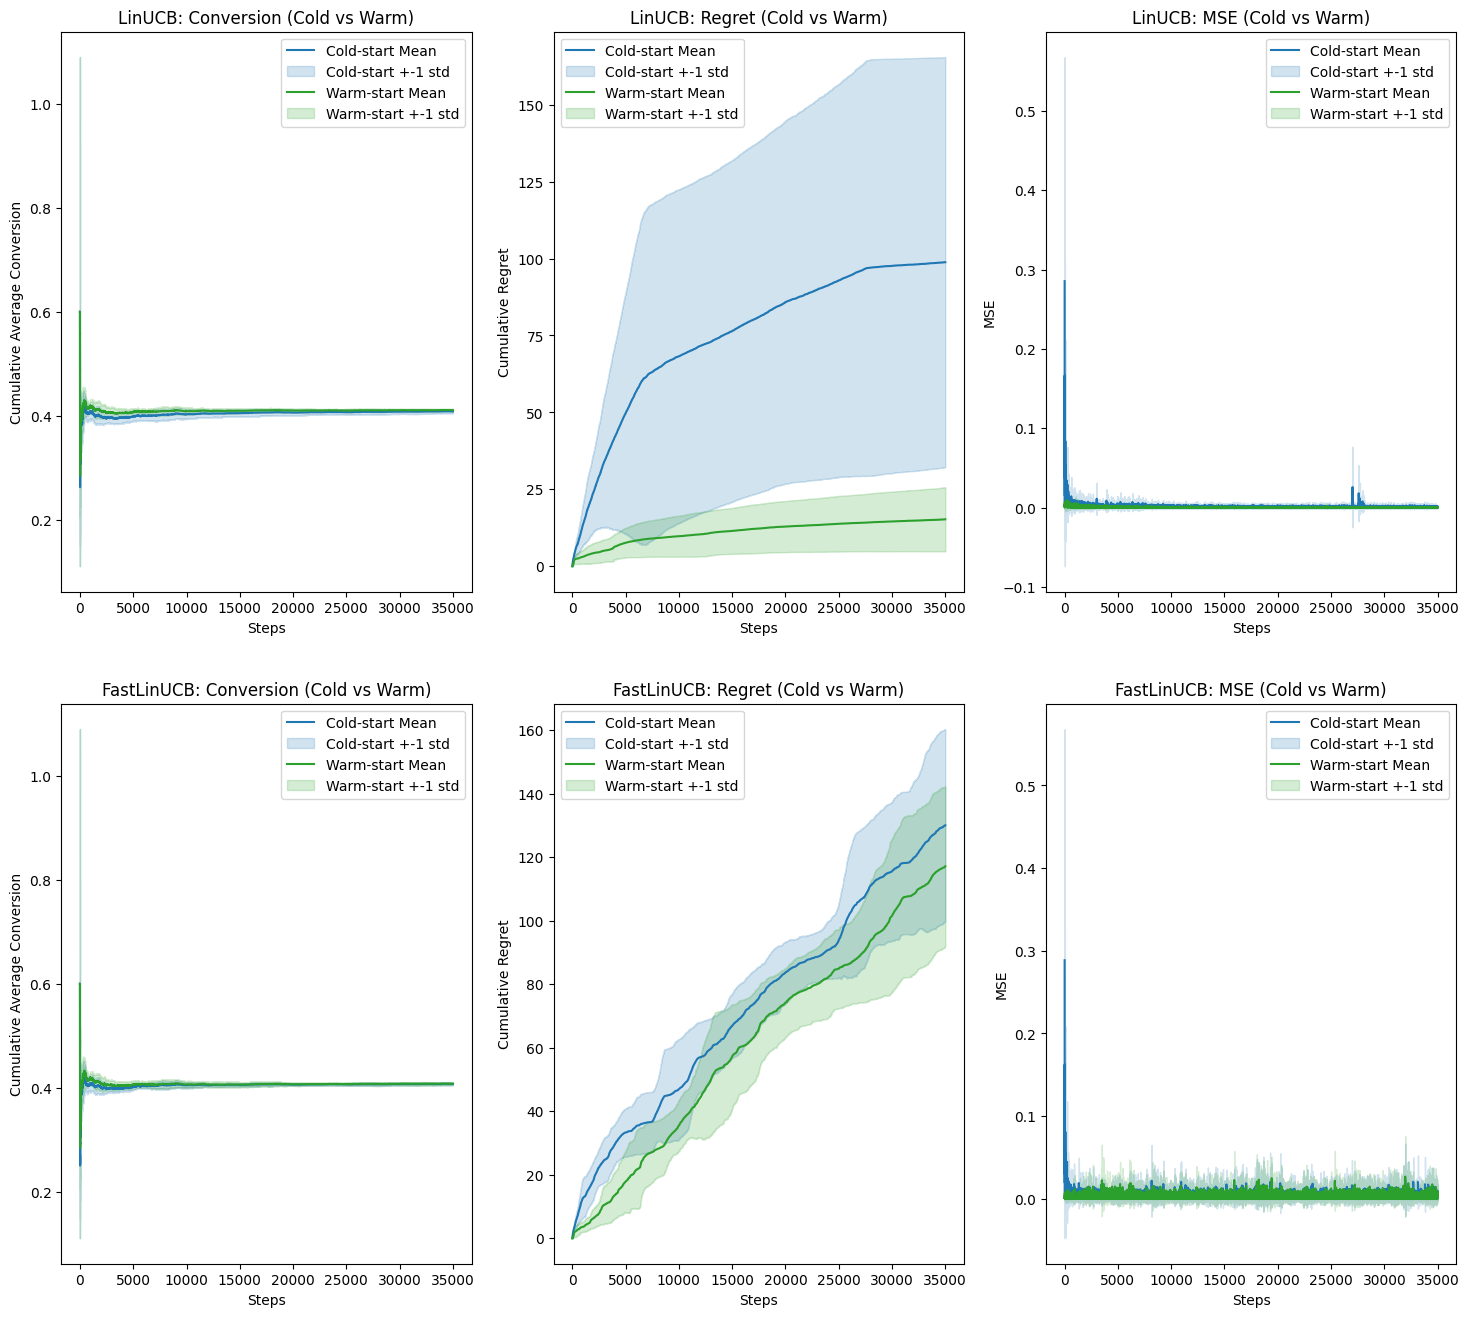

In [8]:
from caudyn.oco.experiments import run_static_warm_start_multi_seed
from caudyn.oco.reporting import plot_cold_vs_warm_start_comparison

print("\n" + "="*70)
print("WARM-START vs COLD-START: All 4 Agents in Static Environment")
print("="*70)

# Extract R-learner priors for warm-start initialization
offline_csv_path = cwd.parent / "historical_marketplace_logs.csv"

# Run cold-start comparison (already have static_result from earlier)
print("\nCold-Start: Already computed (static_result)")

# Run warm-start comparison with offline priors
print("\nWarm-Start: Injecting R-learner priors with prior_weight=30.0...")
warm_start_result = run_static_warm_start_multi_seed(
    offline_csv_path=str(offline_csv_path),
    agent_configs=agent_configs,
    seeds=seeds,
    n_steps=n_steps_static,
    progress_every=5000,
    prior_weight=30.0,
    ridge_alpha=1.0,
    rlearner_cv=5,
    rlearner_random_state=42,
)

print("\n=== Cold-Start Summary ===")
print_multi_seed_summary(static_result)
print("\n=== Warm-Start Summary (R-Learner priors) ===")
print_multi_seed_summary(warm_start_result)

print("\n=== Visualization: Cold vs Warm Start for All 4 Methods ===")
plot_cold_vs_warm_start_comparison(static_result, warm_start_result)
plt.show()

print("\n" + "="*70)
print("KEY INSIGHTS:")
print("="*70)
print("\nWarm-Start Benefits:")
print("  - Reduces early-phase exploration tax by injecting offline causal priors")
print("  - All 4 agents initialize with informed beliefs about per-action rewards")
print("  - Cumulative regret is substantially lower in the first 5,000 steps")
print("  - MSE stabilization is faster due to better initialization")
print("\nCold-Start Vulnerabilities:")
print("  - Agents must randomly explore to map the marketplace")
print("  - Higher variability in early-phase performance across seeds")
print("  - Cumulative regret penalty compounds quickly")
print("\nComparison Across All 4 Methods:")
print("  - LinUCB: Optimal static performance but poor adaptability")
print("  - FastLinUCB: Discounting trades static perfection for robustness")
print("  - LinTS: Posterior sampling provides natural regularization")
print("  - FastLinTS: Combines posterior sampling + discounting for best adaptability")
print("\n" + "="*70)